# MFEX / XDM Practice

**Ядро MFEX без обучения модели:**

1. статистический источник: различие классов, Spearman, Mutual Information, Relief-like;
2. геометрический источник: падение расстояниевой разделимости при удалении признака;
3. условный источник: частная корреляция признака с целью при контроле остальных признаков;
4. структурный источник: интервальные правила подгрупп.

Опциональный блок **MFF-1NN validation** использует 1-NN только как внешний sanity-check качества выбранных признаков.

## 0. Настройки

Для обычной сдачи студент меняет только этот блок:

- `DATA_MODE`: demo или свой CSV;
- `CSV_PATH`: путь к файлу, если используется CSV;
- `TARGET_COLUMN`: имя целевого столбца;
- `DOMAIN`: `medicine`, `economics`, `esg`, `social` или свой домен.

Если целевая переменная количественная, блокнот автоматически сделает бинарную цель: значение выше медианы = 1.

In [1]:
# =========================
# USER CONFIGURATION
# =========================
DATA_MODE = "medical_demo"     # medical_demo, economic_demo, social_demo, csv
CSV_PATH = "your_dataset.csv"  # используется только при DATA_MODE = "csv"
TARGET_COLUMN = "target"       # имя целевого столбца для CSV
DOMAIN = "medicine"            # medicine, economics, esg, social, other
DATASET_NAME = None             # None = взять автоматически; можно вписать название вручную

ANALYSIS_PROFILE = "quick"     # quick, full, extended
RANDOM_STATE = 42
OUT_DIR = "mfex_student_outputs"

# Ограничители скорости. Для больших CSV лучше сначала quick.
MAX_ROWS_FOR_DISTANCE = 700
MAX_FEATURES_FOR_FULL = 80
RELIEF_NEIGHBORS = 8
MFF_RANDOM_REPEATS = 100        # quick: можно 30; full: 100; extended: 300+
BOOTSTRAP_REPEATS = 25          # quick: можно 10; full: 25; extended: 50+

# Валидация через 1-NN. Это НЕ объяснение, только внешний тест выбранных признаков.
RUN_1NN_VALIDATION = False

# Расширенные блоки для доп. балла. По умолчанию выключены, потому что требуют пакетов/времени.
RUN_EXTENDED_SHAP_1NN = False
RUN_EXTENDED_LINGAM = False

## 1. Импорты и подготовка окружения

In [2]:
import os
import sys
import math
import json
import shutil
import subprocess
import importlib.util
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier

# statsmodels нужен только для demo economic/social.
if DATA_MODE in {"economic_demo", "social_demo"} and importlib.util.find_spec("statsmodels") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "statsmodels"])

if DATA_MODE in {"economic_demo", "social_demo"}:
    import statsmodels.api as sm

rng = np.random.default_rng(RANDOM_STATE)
OUT = Path(OUT_DIR)
FIG_DIR = OUT / "figures"
OUT.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

if ANALYSIS_PROFILE == "quick":
    MFF_RANDOM_REPEATS = min(MFF_RANDOM_REPEATS, 30)
    BOOTSTRAP_REPEATS = min(BOOTSTRAP_REPEATS, 10)
elif ANALYSIS_PROFILE == "extended":
    MFF_RANDOM_REPEATS = max(MFF_RANDOM_REPEATS, 300)
    BOOTSTRAP_REPEATS = max(BOOTSTRAP_REPEATS, 50)

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

print("Output folder:", OUT.resolve())
print("Profile:", ANALYSIS_PROFILE, "| MFF repeats:", MFF_RANDOM_REPEATS, "| bootstrap repeats:", BOOTSTRAP_REPEATS)

Output folder: /content/mfex_student_outputs
Profile: quick | MFF repeats: 30 | bootstrap repeats: 10


## 2. Загрузка данных

Демо-режимы нужны для проверки, что блокнот работает. Для сдачи студент обычно выбирает `DATA_MODE = "csv"`.

In [3]:
def load_dataset():
    """Return df, target_col, dataset_name, domain."""
    if DATA_MODE == "medical_demo":
        data = load_breast_cancer(as_frame=True)
        df = data.frame.copy()
        return df, "target", DATASET_NAME or "Breast Cancer Wisconsin", DOMAIN or "medicine"

    if DATA_MODE == "economic_demo":
        macro = sm.datasets.macrodata.load_pandas().data.copy()
        cols = ["realgdp", "realcons", "realinv", "realgovt", "realdpi", "cpi", "m1", "tbilrate", "unemp", "pop", "realint", "infl"]
        df = macro[cols].dropna().copy()
        df["high_inflation"] = (df["infl"] > df["infl"].median()).astype(int)
        df = df.drop(columns=["infl"])
        return df, "high_inflation", DATASET_NAME or "US macrodata high inflation", DOMAIN or "economics"

    if DATA_MODE == "social_demo":
        state = sm.datasets.statecrime.load_pandas().data.reset_index().copy()
        df = state.copy()
        df["high_violent_social_risk"] = (df["violent"] > df["violent"].median()).astype(int)
        drop_cols = [c for c in ["state", "violent"] if c in df.columns]
        df = df.drop(columns=drop_cols)
        return df, "high_violent_social_risk", DATASET_NAME or "US state social indicators", DOMAIN or "social"

    if DATA_MODE == "csv":
        df = pd.read_csv(CSV_PATH)
        if TARGET_COLUMN not in df.columns:
            raise ValueError(f"TARGET_COLUMN={TARGET_COLUMN!r} not found. Available columns: {list(df.columns)[:30]}")
        name = DATASET_NAME or Path(CSV_PATH).stem
        return df, TARGET_COLUMN, name, DOMAIN or "other"

    raise ValueError("Unknown DATA_MODE. Use medical_demo, economic_demo, social_demo or csv.")

raw_df, target_col, dataset_name, domain = load_dataset()
print("Dataset:", dataset_name)
print("Domain:", domain)
print("Shape:", raw_df.shape)
display(raw_df.head())

Dataset: Breast Cancer Wisconsin
Domain: medicine
Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 3. Аудит качества данных и предобработка

Здесь блокнот не обучает модель. Он приводит таблицу к числовому виду, заполняет пропуски и стандартизирует признаки для расстояний/ковариаций.

In [4]:
def make_binary_target(y: pd.Series):
    """Keep binary target; factorize binary categorical; binarize numeric continuous by median."""
    y0 = y.copy()
    missing_target = int(y0.isna().sum())
    if missing_target > 0:
        # Для практики проще удалить строки без цели.
        pass

    non_null = y0.dropna()
    unique_vals = pd.unique(non_null)

    if len(unique_vals) == 2:
        if pd.api.types.is_numeric_dtype(non_null):
            vals = sorted(unique_vals)
            mapped = y0.map({vals[0]: 0, vals[1]: 1})
            return mapped.astype("Int64"), f"binary target: {vals[0]} -> 0, {vals[1]} -> 1"
        codes, uniques = pd.factorize(y0)
        # factorize gives -1 for missing
        mapped = pd.Series(codes, index=y0.index).replace(-1, pd.NA).astype("Int64")
        return mapped, f"binary categorical target factorized: {list(uniques)}"

    if pd.api.types.is_numeric_dtype(non_null):
        med = float(non_null.median())
        mapped = (y0 > med).astype("Int64")
        return mapped, f"numeric target binarized by median: > {med:.6g} -> 1"

    raise ValueError("Target must be binary or numeric. For multiclass target, create a binary target before running MFEX.")


def prepare_table(df: pd.DataFrame, target_col: str):
    df = df.copy()
    y_bin, target_note = make_binary_target(df[target_col])
    keep_rows = y_bin.notna()
    removed_rows = int((~keep_rows).sum())
    df = df.loc[keep_rows].reset_index(drop=True)
    y_bin = y_bin.loc[keep_rows].astype(int).reset_index(drop=True)

    X_raw = df.drop(columns=[target_col]).copy()
    original_feature_count = X_raw.shape[1]

    # Простая обработка признаков: числовые + one-hot для категориальных.
    for c in X_raw.columns:
        if pd.api.types.is_bool_dtype(X_raw[c]):
            X_raw[c] = X_raw[c].astype(int)

    numeric_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in X_raw.columns if c not in numeric_cols]

    X_num = X_raw[numeric_cols].copy()
    for c in X_num.columns:
        X_num[c] = X_num[c].fillna(X_num[c].median())

    if categorical_cols:
        X_cat = X_raw[categorical_cols].astype("object").fillna("__missing__")
        X_cat = pd.get_dummies(X_cat, prefix=categorical_cols, dummy_na=False)
        X_all = pd.concat([X_num, X_cat], axis=1)
    else:
        X_all = X_num

    # Удаляем константы.
    nunique = X_all.nunique(dropna=False)
    constant_cols = nunique[nunique <= 1].index.tolist()
    if constant_cols:
        X_all = X_all.drop(columns=constant_cols)

    if X_all.shape[1] == 0:
        raise ValueError("No usable feature columns after preprocessing.")

    # Защита от слишком широкой таблицы: оставляем признаки с максимальной дисперсией.
    feature_filter_note = "no feature prefilter"
    if X_all.shape[1] > MAX_FEATURES_FOR_FULL:
        variances = X_all.var(numeric_only=True).sort_values(ascending=False)
        keep = variances.head(MAX_FEATURES_FOR_FULL).index.tolist()
        X_all = X_all[keep]
        feature_filter_note = f"kept top {MAX_FEATURES_FOR_FULL} features by variance for speed"

    X_all = X_all.astype(float)
    mean = X_all.mean(axis=0)
    std = X_all.std(axis=0).replace(0, 1)
    X = ((X_all - mean) / std).replace([np.inf, -np.inf], 0.0).fillna(0.0)
    X = X.reset_index(drop=True)

    audit = {
        "dataset": dataset_name,
        "domain": domain,
        "objects_raw": len(raw_df),
        "objects_used": len(X),
        "rows_removed_missing_target": removed_rows,
        "features_original": original_feature_count,
        "features_after_encoding": int(X.shape[1]),
        "target_col_original": target_col,
        "target_note": target_note,
        "class_0_share": float((y_bin == 0).mean()),
        "class_1_share": float((y_bin == 1).mean()),
        "missing_values_raw_total": int(raw_df.isna().sum().sum()),
        "categorical_features_encoded": int(len(categorical_cols)),
        "constant_features_removed": int(len(constant_cols)),
        "feature_filter_note": feature_filter_note,
    }
    return X, y_bin, pd.DataFrame([audit])

X, y, dataset_profile = prepare_table(raw_df, target_col)
dataset_profile.to_csv(OUT / "dataset_profile.csv", index=False)
display(dataset_profile)
print("Prepared X shape:", X.shape)
print("Target distribution:")
display(y.value_counts(normalize=True).sort_index().rename("share").to_frame())

,dataset,domain,objects_raw,objects_used,rows_removed_missing_target,features_original,features_after_encoding,target_col_original,target_note,class_0_share,class_1_share,missing_values_raw_total,categorical_features_encoded,constant_features_removed,feature_filter_note
0,Breast Cancer Wisconsin,medicine,569,569,0,30,30,target,"binary target: 0 -> 0, 1 -> 1",0.372583,0.627417,0,0,0,no feature prefilter


Prepared X shape: (569, 30)
Target distribution:


,share
target,
0,0.372583
1,0.627417


## 4. Вспомогательные функции MFEX

In [5]:
def normalize_score(s):
    s = pd.Series(s, dtype=float).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    s = s - s.min()
    mx = s.max()
    if mx <= 0 or not np.isfinite(mx):
        return pd.Series(np.zeros(len(s)), index=s.index, dtype=float)
    return s / mx


def rank_score(s):
    s = pd.Series(s, dtype=float).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return s.rank(ascending=False, method="average")


def sample_rows_for_distance(X_df, y_ser, max_rows=700):
    n = len(X_df)
    if n <= max_rows:
        return X_df.reset_index(drop=True), y_ser.reset_index(drop=True)
    # Стратифицированная подвыборка без обучения: сохраняем доли классов.
    idx_parts = []
    for cls, part in y_ser.groupby(y_ser).groups.items():
        part = np.asarray(list(part))
        take = max(2, int(round(max_rows * len(part) / n)))
        take = min(take, len(part))
        idx_parts.append(rng.choice(part, size=take, replace=False))
    idx = np.concatenate(idx_parts)
    rng.shuffle(idx)
    return X_df.iloc[idx].reset_index(drop=True), y_ser.iloc[idx].reset_index(drop=True)


def pairwise_distances_np(A):
    A = np.asarray(A, dtype=float)
    aa = np.sum(A * A, axis=1)[:, None]
    d2 = np.maximum(aa + aa.T - 2 * A @ A.T, 0.0)
    return np.sqrt(d2)


def structure_from_distance_matrix(D, y_arr):
    i, j = np.triu_indices_from(D, k=1)
    if len(i) == 0:
        return 0.0
    same = y_arr[i] == y_arr[j]
    if same.all() or (~same).all():
        return 0.0
    intra = D[i, j][same].mean()
    inter = D[i, j][~same].mean()
    return float((inter - intra) / (abs(inter) + abs(intra) + 1e-12))


def distance_structure_score(X_part, y_part, max_rows=MAX_ROWS_FOR_DISTANCE):
    X_s, y_s = sample_rows_for_distance(pd.DataFrame(X_part), pd.Series(y_part), max_rows=max_rows)
    A = np.asarray(X_s, dtype=float)
    if A.ndim == 1:
        A = A.reshape(-1, 1)
    D = pairwise_distances_np(A)
    return structure_from_distance_matrix(D, np.asarray(y_s))


def make_bins(x, bins=5):
    x = pd.Series(x)
    if x.nunique(dropna=True) <= 1:
        return pd.Series([pd.NA] * len(x), index=x.index)
    try:
        return pd.qcut(x, q=bins, duplicates="drop")
    except Exception:
        return pd.cut(x, bins=bins, duplicates="drop")

print("Helper functions ready.")

Helper functions ready.


## 5. Расчёт безмодельных источников важности

Функция ниже считает все основные таблицы. Её можно переиспользовать в bootstrap и для любых CSV.

In [6]:
def class_difference_scores(X_df, y_ser):
    out = {}
    for c in X_df.columns:
        x0 = X_df.loc[y_ser == 0, c]
        x1 = X_df.loc[y_ser == 1, c]
        pooled = math.sqrt(float((x0.var() + x1.var()) / 2.0)) + 1e-12
        out[c] = abs(float(x1.mean() - x0.mean())) / pooled
    return normalize_score(pd.Series(out))


def spearman_scores(X_df, y_ser):
    out = {}
    for c in X_df.columns:
        val = spearmanr(X_df[c], y_ser).correlation
        out[c] = abs(float(val)) if val is not None and np.isfinite(val) else 0.0
    return normalize_score(pd.Series(out))


def mutual_information_scores(X_df, y_ser):
    try:
        vals = mutual_info_classif(X_df.values, y_ser.values, discrete_features=False, random_state=RANDOM_STATE)
        return normalize_score(pd.Series(vals, index=X_df.columns))
    except Exception as e:
        print("MI fallback because sklearn mutual_info_classif failed:", repr(e))
        # Дискретная fallback-оценка.
        scores = {}
        for c in X_df.columns:
            b = make_bins(X_df[c], bins=6)
            tab = pd.crosstab(b, y_ser, normalize=True)
            px = tab.sum(axis=1).values
            py = tab.sum(axis=0).values
            pxy = tab.values
            s = 0.0
            for i in range(pxy.shape[0]):
                for j in range(pxy.shape[1]):
                    if pxy[i, j] > 0 and px[i] > 0 and py[j] > 0:
                        s += pxy[i, j] * np.log(pxy[i, j] / (px[i] * py[j]))
            scores[c] = s
        return normalize_score(pd.Series(scores))


def relief_like_scores(X_df, y_ser, neighbors=RELIEF_NEIGHBORS, max_rows=MAX_ROWS_FOR_DISTANCE):
    X_s, y_s = sample_rows_for_distance(X_df, y_ser, max_rows=max_rows)
    A = X_s.values.astype(float)
    y_arr = y_s.values
    n, p = A.shape
    D = pairwise_distances_np(A)
    np.fill_diagonal(D, np.inf)
    scores = np.zeros(p, dtype=float)
    for i in range(n):
        same_idx = np.where(y_arr == y_arr[i])[0]
        diff_idx = np.where(y_arr != y_arr[i])[0]
        same_idx = same_idx[same_idx != i]
        if len(same_idx) == 0 or len(diff_idx) == 0:
            continue
        k_hit = min(neighbors, len(same_idx))
        k_miss = min(neighbors, len(diff_idx))
        hit = same_idx[np.argsort(D[i, same_idx])[:k_hit]]
        miss = diff_idx[np.argsort(D[i, diff_idx])[:k_miss]]
        scores += np.mean(np.abs(A[i] - A[miss]), axis=0) - np.mean(np.abs(A[i] - A[hit]), axis=0)
    return normalize_score(pd.Series(scores / max(n, 1), index=X_s.columns).reindex(X_df.columns).fillna(0.0))


def geometry_drop_scores(X_df, y_ser, max_rows=MAX_ROWS_FOR_DISTANCE):
    X_s, y_s = sample_rows_for_distance(X_df, y_ser, max_rows=max_rows)
    A = X_s.values.astype(float)
    cols = X_s.columns.tolist()
    base_D = pairwise_distances_np(A)
    base_score = structure_from_distance_matrix(base_D, y_s.values)
    # Используем квадрат расстояния, чтобы быстрее удалять один признак.
    base_D2 = base_D ** 2
    scores = {}
    for j, c in enumerate(cols):
        diff2 = (A[:, [j]] - A[:, [j]].T) ** 2
        D_without = np.sqrt(np.maximum(base_D2 - diff2, 0.0))
        without_score = structure_from_distance_matrix(D_without, y_s.values)
        scores[c] = max(base_score - without_score, 0.0)
    return normalize_score(pd.Series(scores).reindex(X_df.columns).fillna(0.0))


def conditional_partial_corr_scores(X_df, y_ser):
    Xy = X_df.copy()
    Xy["__target__"] = y_ser.values
    Z = (Xy - Xy.mean()) / Xy.std().replace(0, 1)
    Z = Z.replace([np.inf, -np.inf], 0.0).fillna(0.0)
    P = np.linalg.pinv(np.cov(Z.values, rowvar=False))
    t = list(Z.columns).index("__target__")
    out = {}
    for i, c in enumerate(X_df.columns):
        denom = math.sqrt(abs(float(P[i, i] * P[t, t]))) + 1e-12
        out[c] = abs(float(-P[i, t] / denom))
    return normalize_score(pd.Series(out))


def subgroup_rule_scores(X_df, y_ser, bins=5, top_rules_per_dataset=60):
    base_rate = float(y_ser.mean())
    min_support = max(6, int(0.03 * len(X_df)))
    rows = []
    scores = pd.Series(0.0, index=X_df.columns)
    for c in X_df.columns:
        binned = make_bins(X_df[c], bins=bins)
        for interval in binned.dropna().unique():
            mask = (binned == interval)
            support = int(mask.sum())
            if support < min_support:
                continue
            rate = float(y_ser[mask].mean())
            coverage = float(mask.mean())
            quality = coverage * abs(rate - base_rate)
            lift = (rate / base_rate) if base_rate > 0 else np.nan
            rows.append({
                "dataset": dataset_name,
                "domain": domain,
                "feature": c,
                "interval": str(interval),
                "support": support,
                "coverage": coverage,
                "target_rate_in_rule": rate,
                "base_target_rate": base_rate,
                "lift_vs_base": lift,
                "rule_score": quality,
            })
    rules = pd.DataFrame(rows)
    if len(rules):
        rules = rules.sort_values("rule_score", ascending=False).reset_index(drop=True)
        for feat, part in rules.head(top_rules_per_dataset).groupby("feature"):
            scores.loc[feat] = part["rule_score"].sum()
    else:
        rules = pd.DataFrame(columns=["dataset", "domain", "feature", "interval", "support", "coverage", "target_rate_in_rule", "base_target_rate", "lift_vs_base", "rule_score"])
    return normalize_score(scores), rules


def redundancy_table(X_df, top_features=None):
    if top_features is None:
        top_features = X_df.columns.tolist()
    corr = X_df.corr(method="spearman").abs().fillna(0.0)
    rows = []
    for c in top_features:
        others = corr.loc[c].drop(index=c, errors="ignore")
        if len(others) == 0:
            rows.append({"feature": c, "max_abs_spearman_with_other_feature": 0.0, "nearest_redundant_feature": ""})
        else:
            mx_feat = others.idxmax()
            rows.append({"feature": c, "max_abs_spearman_with_other_feature": float(others.loc[mx_feat]), "nearest_redundant_feature": mx_feat})
    return pd.DataFrame(rows)


def build_scores_and_ranks(X_df, y_ser):
    class_diff = class_difference_scores(X_df, y_ser)
    rank_rel = spearman_scores(X_df, y_ser)
    mi = mutual_information_scores(X_df, y_ser)
    relief = relief_like_scores(X_df, y_ser)
    statistical = normalize_score((class_diff + rank_rel + mi + relief) / 4.0)

    geometry = geometry_drop_scores(X_df, y_ser)
    conditional = conditional_partial_corr_scores(X_df, y_ser)
    structural, rules = subgroup_rule_scores(X_df, y_ser)

    method_scores = pd.DataFrame({
        "class_difference": class_diff,
        "rank_relation_spearman": rank_rel,
        "mutual_information": mi,
        "relief_like": relief,
        "statistical_core": statistical,
        "geometry_drop": geometry,
        "conditional_partial_corr": conditional,
        "structural_rules": structural,
    })

    core_scores = pd.DataFrame({
        "statistical": statistical,
        "geometric": geometry,
        "conditional": conditional,
        "structural": structural,
    })

    ranks = core_scores.apply(rank_score, axis=0)
    ranks["median_rank"] = ranks.median(axis=1)
    ranks["mean_rank"] = ranks.mean(axis=1)
    ranks["rank_iqr"] = ranks[core_scores.columns].quantile(0.75, axis=1) - ranks[core_scores.columns].quantile(0.25, axis=1)
    ranks["rank_range"] = ranks[core_scores.columns].max(axis=1) - ranks[core_scores.columns].min(axis=1)
    ranks["stable"] = ranks["rank_iqr"] <= ranks["rank_iqr"].median()
    ranks = ranks.sort_values(["median_rank", "rank_iqr", "mean_rank"])
    ranks.insert(0, "feature", ranks.index)
    ranks.insert(0, "domain", domain)
    ranks.insert(0, "dataset", dataset_name)

    red = redundancy_table(X_df, ranks["feature"].head(30).tolist())
    ranks = ranks.merge(red, on="feature", how="left")
    return method_scores, core_scores, ranks, rules

method_scores, core_scores, ranks, rules = build_scores_and_ranks(X, y)
method_scores.to_csv(OUT / "xdm_method_scores.csv", index_label="feature")
core_scores.to_csv(OUT / "mfex_core_scores.csv", index_label="feature")
ranks.to_csv(OUT / "xdm_feature_importance_ranks.csv", index=False)
rules.to_csv(OUT / "xdm_top_rules.csv", index=False)

display(ranks.head(15))
display(rules.head(10))

,dataset,domain,feature,statistical,geometric,conditional,structural,median_rank,mean_rank,rank_iqr,rank_range,stable,max_abs_spearman_with_other_feature,nearest_redundant_feature
0,Breast Cancer Wisconsin,medicine,worst perimeter,1.0,1.0,23.0,1.0,1.0,5.4,5.50,22.0,False,0.993548,worst radius
1,Breast Cancer Wisconsin,medicine,worst radius,2.0,2.0,1.0,5.0,2.0,2.4,1.00,4.0,True,0.998891,worst area
2,Breast Cancer Wisconsin,medicine,worst area,4.0,4.0,3.0,4.0,4.0,3.8,0.25,1.0,True,0.998891,worst radius
3,Breast Cancer Wisconsin,medicine,mean concave points,5.0,3.0,13.0,2.0,4.0,5.4,4.25,11.0,False,0.937075,worst concave points
4,Breast Cancer Wisconsin,medicine,worst concave points,3.0,5.0,22.0,3.0,4.0,7.4,6.25,19.0,False,0.937075,mean concave points
5,Breast Cancer Wisconsin,medicine,mean perimeter,6.0,7.0,15.0,8.0,7.5,8.7,3.00,9.0,True,0.997802,mean radius
6,Breast Cancer Wisconsin,medicine,mean area,8.0,6.0,19.0,9.0,8.5,10.1,4.00,13.0,False,0.999602,mean radius
7,Breast Cancer Wisconsin,medicine,mean concavity,9.0,9.0,10.0,6.0,9.0,8.6,1.00,4.0,True,0.938543,worst concavity
8,Breast Cancer Wisconsin,medicine,mean radius,7.0,8.0,11.0,10.0,9.0,9.0,2.50,4.0,True,0.999602,mean area
9,Breast Cancer Wisconsin,medicine,worst concavity,10.0,11.0,8.0,7.0,9.0,9.0,2.50,4.0,True,0.938543,mean concavity


,dataset,domain,feature,interval,support,coverage,target_rate_in_rule,base_target_rate,lift_vs_base,rule_score
0,Breast Cancer Wisconsin,medicine,worst radius,"(0.833, 4.091]",114,0.200351,0.000000,0.627417,0.000000,0.125704
1,Breast Cancer Wisconsin,medicine,worst concave points,"(0.957, 2.684]",114,0.200351,0.000000,0.627417,0.000000,0.125704
2,Breast Cancer Wisconsin,medicine,worst perimeter,"(0.781, 4.284]",113,0.198594,0.000000,0.627417,0.000000,0.124601
3,Breast Cancer Wisconsin,medicine,worst area,"(0.682, 5.925]",113,0.198594,0.000000,0.627417,0.000000,0.124601
4,Breast Cancer Wisconsin,medicine,mean radius,"(0.834, 3.968]",114,0.200351,0.008772,0.627417,0.013981,0.123946
5,Breast Cancer Wisconsin,medicine,mean perimeter,"(0.811, 3.973]",114,0.200351,0.008772,0.627417,0.013981,0.123946
6,Breast Cancer Wisconsin,medicine,mean area,"(0.739, 5.246]",114,0.200351,0.008772,0.627417,0.013981,0.123946
7,Breast Cancer Wisconsin,medicine,mean concave points,"(0.911, 3.924]",114,0.200351,0.008772,0.627417,0.013981,0.123946
8,Breast Cancer Wisconsin,medicine,area error,"(0.302, 11.032]",114,0.200351,0.008772,0.627417,0.013981,0.123946
9,Breast Cancer Wisconsin,medicine,mean concavity,"(0.765, 4.24]",114,0.200351,0.061404,0.627417,0.097867,0.113402


## 6. Согласованность методов

Если согласованность низкая, это не провал. Это сигнал, что разные источники видят разные стороны данных.

In [7]:
def method_agreement(ranks_df):
    core_cols = ["statistical", "geometric", "conditional", "structural"]
    mat = pd.DataFrame(np.eye(len(core_cols)), index=core_cols, columns=core_cols)
    for a, b in combinations(core_cols, 2):
        rho = spearmanr(ranks_df[a], ranks_df[b]).correlation
        rho = float(rho) if rho is not None and np.isfinite(rho) else 0.0
        mat.loc[a, b] = rho
        mat.loc[b, a] = rho
    rows = []
    for a, b in combinations(core_cols, 2):
        rows.append({"dataset": dataset_name, "domain": domain, "method_a": a, "method_b": b, "spearman_rho": mat.loc[a, b]})
    long = pd.DataFrame(rows)
    return mat, long

agreement_matrix, agreement_long = method_agreement(ranks)
agreement_matrix.to_csv(OUT / "method_agreement_matrix.csv")
agreement_long.to_csv(OUT / "method_agreement_long.csv", index=False)

print("Mean pairwise Spearman agreement:", round(float(agreement_long["spearman_rho"].mean()), 4))
display(agreement_matrix)

Mean pairwise Spearman agreement: 0.6164


,statistical,geometric,conditional,structural
statistical,1.000000,0.923749,0.279199,0.962091
geometric,0.923749,1.000000,0.245620,0.928662
conditional,0.279199,0.245620,1.000000,0.359324
structural,0.962091,0.928662,0.359324,1.000000


## 7. MFF-NoFit: проверка консенсуса без обучения модели

MFF-NoFit сравнивает top-k признаков по консенсусу со случайными наборами той же мощности.

In [8]:
def mff_nofit_for_k(X_df, y_ser, ordered_features, k, repeats=MFF_RANDOM_REPEATS):
    ordered_features = [f for f in ordered_features if f in X_df.columns]
    k = int(k)
    if k < 1 or k > len(ordered_features):
        return None, None
    chosen = ordered_features[:k]
    consensus_score = distance_structure_score(X_df[chosen], y_ser)
    random_scores = []
    all_features = ordered_features.copy()
    for _ in range(repeats):
        rnd = rng.choice(all_features, size=k, replace=False).tolist()
        random_scores.append(distance_structure_score(X_df[rnd], y_ser))
    random_scores = np.asarray(random_scores, dtype=float)
    row = {
        "dataset": dataset_name,
        "domain": domain,
        "k": k,
        "consensus_score": consensus_score,
        "random_mean": float(random_scores.mean()),
        "random_std": float(random_scores.std(ddof=1)) if len(random_scores) > 1 else 0.0,
        "MFF_NoFit": float(consensus_score - random_scores.mean()),
        "p_value": float((np.sum(random_scores >= consensus_score) + 1) / (len(random_scores) + 1)),
        "chosen_features": ", ".join(chosen),
    }
    return row, random_scores

ordered_features = ranks["feature"].tolist()
stable_features = ranks.loc[ranks["stable"], "feature"].tolist()
k_values = [3, 5, 10, len(stable_features)]
k_values = sorted({k for k in k_values if 1 <= k <= len(ordered_features)})

mff_rows = []
random_distributions = {}
for k in k_values:
    row, rnd = mff_nofit_for_k(X, y, ordered_features, k)
    if row is not None:
        mff_rows.append(row)
        random_distributions[k] = rnd
mff = pd.DataFrame(mff_rows)
mff.to_csv(OUT / "xdm_mff_nofit_results.csv", index=False)
display(mff)

,dataset,domain,k,consensus_score,random_mean,random_std,MFF_NoFit,p_value,chosen_features
0,Breast Cancer Wisconsin,medicine,3,0.464097,0.221669,0.081181,0.242428,0.032258,"worst perimeter, worst radius, worst area"
1,Breast Cancer Wisconsin,medicine,5,0.434599,0.228840,0.060574,0.205760,0.032258,"worst perimeter, worst radius, worst area, mea..."
2,Breast Cancer Wisconsin,medicine,10,0.394512,0.195953,0.039882,0.198558,0.032258,"worst perimeter, worst radius, worst area, mea..."
3,Breast Cancer Wisconsin,medicine,16,0.334566,0.199646,0.023218,0.134920,0.032258,"worst perimeter, worst radius, worst area, mea..."


## 8. MFF threshold sweep

Этот блок полезен для статьи: показывает, как порог устойчивости по IQR влияет на число стабильных признаков и MFF-NoFit.

In [9]:
def threshold_sweep(X_df, y_ser, ranks_df):
    out = []
    ordered = ranks_df["feature"].tolist()
    iqr_values = ranks_df["rank_iqr"].values
    for q in [0.25, 0.50, 0.75, 1.00]:
        threshold = float(np.quantile(iqr_values, q))
        stable = ranks_df.loc[ranks_df["rank_iqr"] <= threshold, "feature"].tolist()
        k = len(stable)
        if k < 1:
            continue
        row, _ = mff_nofit_for_k(X_df, y_ser, ordered, k, repeats=max(10, MFF_RANDOM_REPEATS // 3))
        row.update({"iqr_quantile_threshold": q, "iqr_threshold_value": threshold, "stable_feature_count": k})
        out.append(row)
    return pd.DataFrame(out)

threshold_results = threshold_sweep(X, y, ranks)
threshold_results.to_csv(OUT / "mff_threshold_sweep.csv", index=False)
display(threshold_results)

,dataset,domain,k,consensus_score,random_mean,random_std,MFF_NoFit,p_value,chosen_features,iqr_quantile_threshold,iqr_threshold_value,stable_feature_count
0,Breast Cancer Wisconsin,medicine,8,0.412997,0.208493,3.452091e-02,0.204505,0.090909,"worst perimeter, worst radius, worst area, mea...",0.25,2.53125,8
1,Breast Cancer Wisconsin,medicine,16,0.334566,0.186322,3.120462e-02,0.148244,0.090909,"worst perimeter, worst radius, worst area, mea...",0.50,3.62500,16
2,Breast Cancer Wisconsin,medicine,22,0.263519,0.205252,2.420653e-02,0.058267,0.090909,"worst perimeter, worst radius, worst area, mea...",0.75,5.21875,22
3,Breast Cancer Wisconsin,medicine,30,0.196860,0.196860,3.700743e-17,0.000000,1.000000,"worst perimeter, worst radius, worst area, mea...",1.00,8.37500,30


## 9. Bootstrap-устойчивость top-признаков

Пересэмплируем строки и считаем, как часто признак попадает в top-10 консенсуса.

In [10]:
def bootstrap_stability(X_df, y_ser, repeats=BOOTSTRAP_REPEATS, top_n=10):
    counts = pd.Series(0.0, index=X_df.columns)
    n = len(X_df)
    for b in range(repeats):
        idx = rng.choice(np.arange(n), size=n, replace=True)
        X_b = X_df.iloc[idx].reset_index(drop=True)
        y_b = y_ser.iloc[idx].reset_index(drop=True)
        try:
            _, _, rb, _ = build_scores_and_ranks(X_b, y_b)
            top = rb["feature"].head(min(top_n, len(rb))).tolist()
            counts.loc[top] += 1
        except Exception as e:
            print(f"bootstrap iteration {b} skipped:", repr(e))
    out = pd.DataFrame({
        "dataset": dataset_name,
        "domain": domain,
        "feature": counts.index,
        "top10_frequency": counts.values / max(repeats, 1),
    }).sort_values("top10_frequency", ascending=False)
    return out

stability = bootstrap_stability(X, y)
stability.to_csv(OUT / "bootstrap_stability.csv", index=False)
display(stability.head(15))

,dataset,domain,feature,top10_frequency
0,Breast Cancer Wisconsin,medicine,mean radius,1.0
2,Breast Cancer Wisconsin,medicine,mean perimeter,1.0
3,Breast Cancer Wisconsin,medicine,mean area,1.0
6,Breast Cancer Wisconsin,medicine,mean concavity,1.0
7,Breast Cancer Wisconsin,medicine,mean concave points,1.0
20,Breast Cancer Wisconsin,medicine,worst radius,1.0
22,Breast Cancer Wisconsin,medicine,worst perimeter,1.0
23,Breast Cancer Wisconsin,medicine,worst area,1.0
27,Breast Cancer Wisconsin,medicine,worst concave points,1.0
26,Breast Cancer Wisconsin,medicine,worst concavity,0.9


## 10. Визуализации

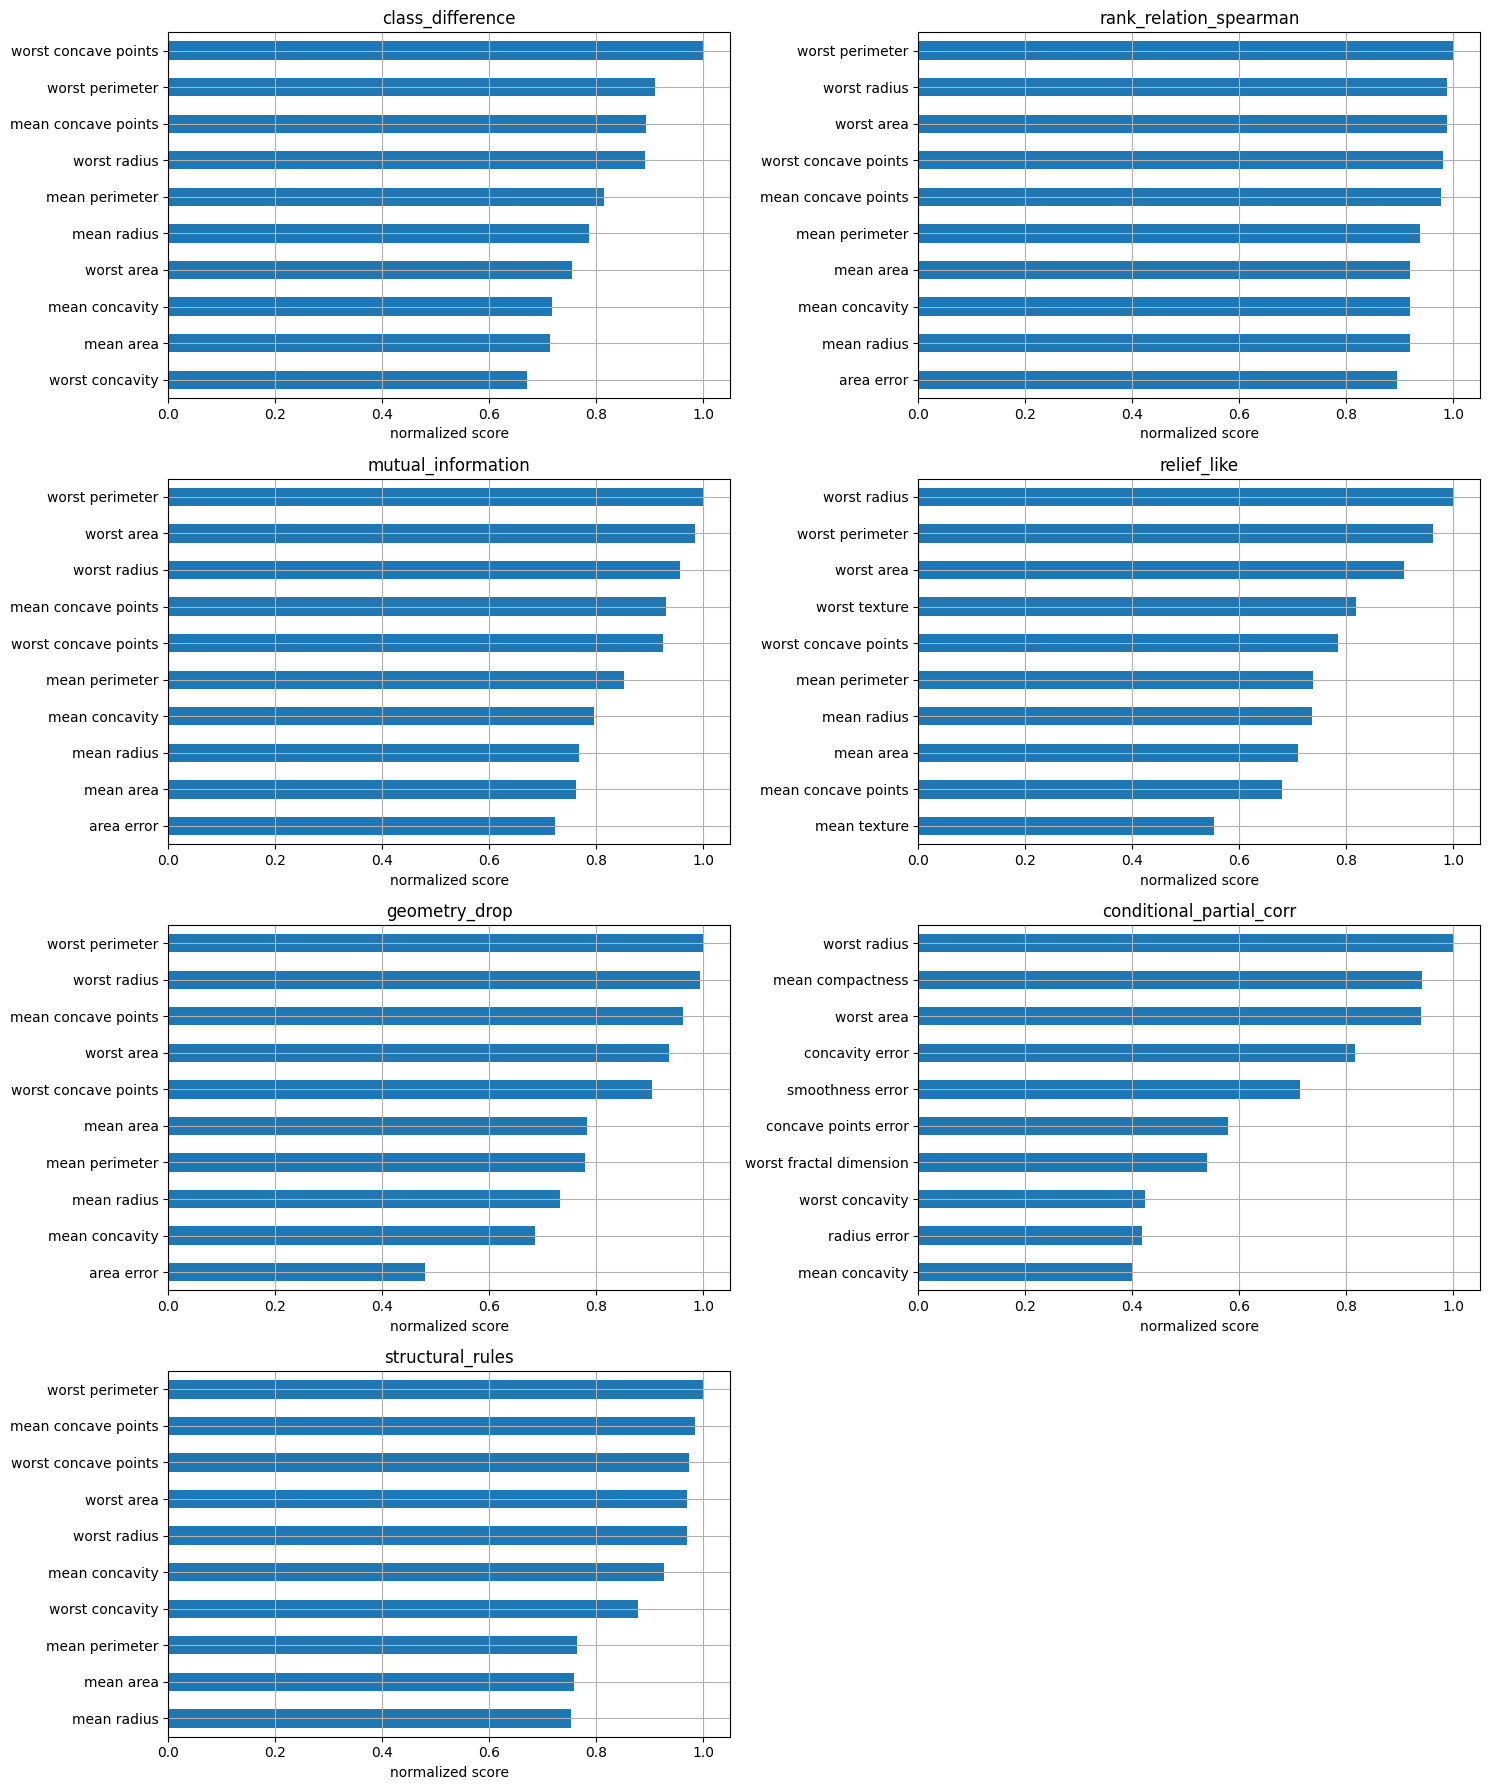

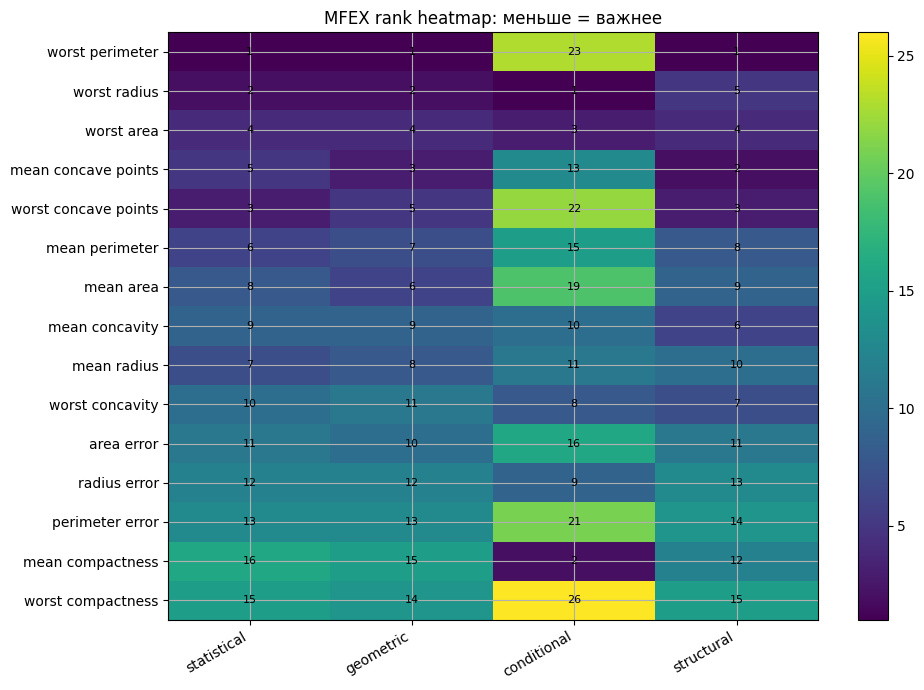

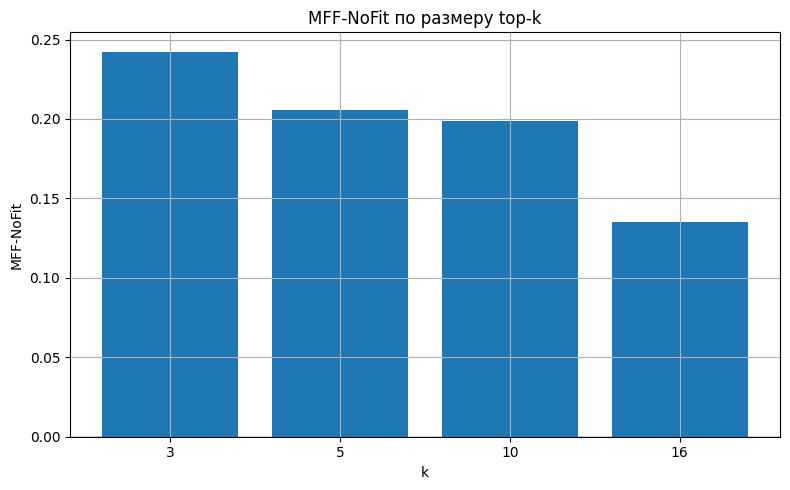

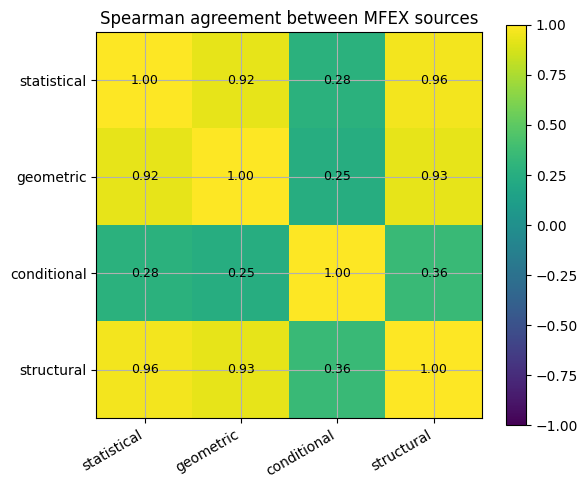

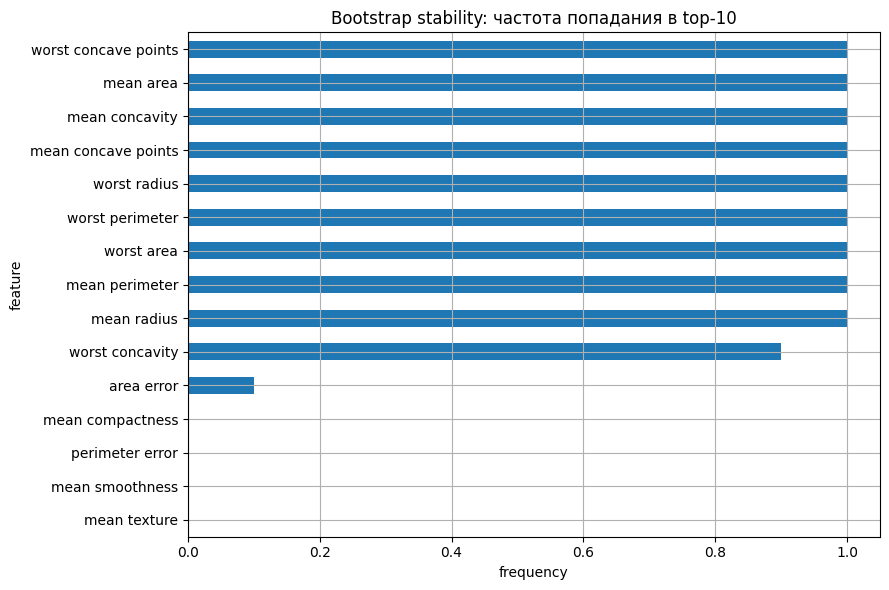

In [11]:
# 10.1 Top-10 по всем методам
plot_cols = ["class_difference", "rank_relation_spearman", "mutual_information", "relief_like", "geometry_drop", "conditional_partial_corr", "structural_rules"]
fig, axes = plt.subplots(4, 2, figsize=(15, 18))
axes = axes.ravel()
for ax, col in zip(axes, plot_cols):
    method_scores[col].sort_values().tail(10).plot(kind="barh", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("normalized score")
for ax in axes[len(plot_cols):]:
    ax.axis("off")
plt.tight_layout()
fig.savefig(FIG_DIR / "top10_by_methods.png", dpi=180, bbox_inches="tight")
plt.show()

# 10.2 Heatmap рангов core-методов
core_cols = ["statistical", "geometric", "conditional", "structural"]
heat = ranks.head(15).set_index("feature")[core_cols]
fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(heat.values, aspect="auto")
ax.set_xticks(range(len(core_cols)))
ax.set_xticklabels(core_cols, rotation=30, ha="right")
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, str(int(heat.values[i, j])), ha="center", va="center", fontsize=8)
ax.set_title("MFEX rank heatmap: меньше = важнее")
fig.colorbar(im, ax=ax)
plt.tight_layout()
fig.savefig(FIG_DIR / "mfex_rank_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

# 10.3 MFF-NoFit
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(mff["k"].astype(str), mff["MFF_NoFit"])
ax.axhline(0, lw=1)
ax.set_title("MFF-NoFit по размеру top-k")
ax.set_xlabel("k")
ax.set_ylabel("MFF-NoFit")
plt.tight_layout()
fig.savefig(FIG_DIR / "mff_nofit_by_k.png", dpi=180, bbox_inches="tight")
plt.show()

# 10.4 Согласованность методов
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(agreement_matrix.values, vmin=-1, vmax=1)
ax.set_xticks(range(len(agreement_matrix.columns)))
ax.set_xticklabels(agreement_matrix.columns, rotation=30, ha="right")
ax.set_yticks(range(len(agreement_matrix.index)))
ax.set_yticklabels(agreement_matrix.index)
for i in range(agreement_matrix.shape[0]):
    for j in range(agreement_matrix.shape[1]):
        ax.text(j, i, f"{agreement_matrix.values[i, j]:.2f}", ha="center", va="center", fontsize=9)
ax.set_title("Spearman agreement between MFEX sources")
fig.colorbar(im, ax=ax)
plt.tight_layout()
fig.savefig(FIG_DIR / "method_agreement_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

# 10.5 Bootstrap stability
fig, ax = plt.subplots(figsize=(9, 6))
stability.head(15).sort_values("top10_frequency").plot(x="feature", y="top10_frequency", kind="barh", legend=False, ax=ax)
ax.set_title("Bootstrap stability: частота попадания в top-10")
ax.set_xlabel("frequency")
plt.tight_layout()
fig.savefig(FIG_DIR / "bootstrap_stability.png", dpi=180, bbox_inches="tight")
plt.show()

## 11. Опциональная проверка через 1-NN

Этот блок нужен только как **валидация**, не как источник объяснения. В статье его можно подавать как robustness/sanity-check: признаки выбраны без модели, а lazy-классификатор проверяет, лучше ли они случайного выбора.

In [12]:
def one_nn_validation(X_df, y_ser, ordered_features, k_values, random_repeats=30):
    rows = []
    y_arr = y_ser.values
    class_counts = pd.Series(y_arr).value_counts()
    n_splits = int(min(5, class_counts.min()))
    if n_splits < 2:
        return pd.DataFrame()
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    all_features = ordered_features.copy()

    def eval_features(feats):
        accs, aucs = [], []
        X_sub = X_df[feats].values
        for tr, te in cv.split(X_sub, y_arr):
            clf = KNeighborsClassifier(n_neighbors=1)
            clf.fit(X_sub[tr], y_arr[tr])
            pred = clf.predict(X_sub[te])
            accs.append(accuracy_score(y_arr[te], pred))
            try:
                proba = clf.predict_proba(X_sub[te])[:, 1]
                aucs.append(roc_auc_score(y_arr[te], proba))
            except Exception:
                aucs.append(np.nan)
        return float(np.mean(accs)), float(np.nanmean(aucs))

    for k in k_values:
        if k < 1 or k > len(all_features):
            continue
        chosen = ordered_features[:k]
        acc, auc = eval_features(chosen)
        rnd_accs, rnd_aucs = [], []
        for _ in range(random_repeats):
            rnd = rng.choice(all_features, size=k, replace=False).tolist()
            a, u = eval_features(rnd)
            rnd_accs.append(a)
            rnd_aucs.append(u)
        rows.append({
            "dataset": dataset_name,
            "domain": domain,
            "k": k,
            "consensus_accuracy_1nn": acc,
            "random_accuracy_mean_1nn": float(np.mean(rnd_accs)),
            "delta_accuracy_1nn": float(acc - np.mean(rnd_accs)),
            "consensus_auc_1nn": auc,
            "random_auc_mean_1nn": float(np.nanmean(rnd_aucs)),
            "delta_auc_1nn": float(auc - np.nanmean(rnd_aucs)),
            "note": "1-NN is validation only; it is not used for MFEX explanation",
        })
    return pd.DataFrame(rows)

if RUN_1NN_VALIDATION:
    validation_repeats = 5 if ANALYSIS_PROFILE == "quick" else (15 if ANALYSIS_PROFILE == "full" else 30)
    mff_1nn = one_nn_validation(X, y, ordered_features, k_values, random_repeats=validation_repeats)
else:
    mff_1nn = pd.DataFrame()

mff_1nn.to_csv(OUT / "mff_1nn_validation.csv", index=False)
display(mff_1nn)

""


## 12. Расширенный анализ для доп. балла: SHAP@1NN и LiNGAM

По умолчанию этот блок выключен. Включайте только если нужно показать анализ сверх базового шаблона.

- **SHAP@1NN**: технически используется lazy-модель 1-NN, но результат не входит в ядро MFEX.
- **LiNGAM**: это гипотезы о направленных связях при сильных предпосылках, а не доказанная причинность.

In [13]:
# --- Optional SHAP@1NN ---
if RUN_EXTENDED_SHAP_1NN:
    if importlib.util.find_spec("shap") is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "shap"])
    import shap

    # Берём подвыборку, иначе KernelExplainer будет очень долгим.
    X_s, y_s = sample_rows_for_distance(X, y, max_rows=min(250, MAX_ROWS_FOR_DISTANCE))
    background = shap.sample(X_s, min(50, len(X_s)), random_state=RANDOM_STATE)
    explain_sample = shap.sample(X_s, min(80, len(X_s)), random_state=RANDOM_STATE)

    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X_s.values, y_s.values)  # lazy-storage для проверки геометрии; не источник MFEX-консенсуса

    explainer = shap.KernelExplainer(lambda z: knn.predict_proba(z)[:, 1], background.values)
    shap_values = explainer.shap_values(explain_sample.values, nsamples=100)
    shap_imp = pd.Series(np.abs(shap_values).mean(axis=0), index=X.columns).sort_values(ascending=False)
    shap_imp.to_csv(OUT / "extended_shap_1nn_importance.csv", header=["shap_1nn_importance"])
    display(shap_imp.head(15).to_frame("shap_1nn_importance"))

# --- Optional LiNGAM ---
if RUN_EXTENDED_LINGAM:
    if importlib.util.find_spec("lingam") is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "lingam"])
    import lingam

    Xy = X.copy()
    Xy["__target__"] = y.values
    X_l, _ = sample_rows_for_distance(Xy, y, max_rows=min(500, MAX_ROWS_FOR_DISTANCE))
    model = lingam.DirectLiNGAM(random_state=RANDOM_STATE)
    model.fit(X_l.values)
    adj = pd.DataFrame(model.adjacency_matrix_, index=X_l.columns, columns=X_l.columns)
    target_effect = adj.loc["__target__"].drop(index="__target__", errors="ignore").abs().sort_values(ascending=False)
    adj.to_csv(OUT / "extended_lingam_adjacency.csv")
    target_effect.to_csv(OUT / "extended_lingam_target_importance.csv", header=["abs_direct_effect_to_target"])
    display(target_effect.head(15).to_frame("abs_direct_effect_to_target"))

## 13. Автоотчёт

Этот текст можно вставить в работу и дополнить предметной интерпретацией.

In [14]:
def make_report():
    top5 = ranks["feature"].head(5).tolist()
    stable_count = int(ranks["stable"].sum())
    mean_agreement = float(agreement_long["spearman_rho"].mean()) if len(agreement_long) else np.nan
    best_mff_row = mff.sort_values("k").iloc[0] if len(mff) else None
    best_rule = rules.iloc[0] if len(rules) else None

    lines = []
    lines.append(f"# MFEX/XDM report: {dataset_name}\n")
    lines.append(f"**Domain:** {domain}\n")
    lines.append("## Dataset audit\n")
    for col, val in dataset_profile.iloc[0].items():
        lines.append(f"- **{col}:** {val}")
    lines.append("\n## Consensus features\n")
    lines.append("Top-5 consensus features: " + ", ".join(top5) + ".")
    lines.append(f"Stable features by IQR threshold: {stable_count}.")
    lines.append(f"Mean pairwise Spearman agreement between MFEX sources: {mean_agreement:.4f}.")
    lines.append("\n## MFF-NoFit\n")
    if best_mff_row is not None:
        lines.append(f"For k={int(best_mff_row['k'])}, MFF-NoFit = {best_mff_row['MFF_NoFit']:.4f}, permutation p-value = {best_mff_row['p_value']:.4f}.")
        if best_mff_row["MFF_NoFit"] > 0:
            lines.append("Interpretation: the consensus feature set preserves target structure better than an average random feature set of the same size.")
        else:
            lines.append("Interpretation: the consensus feature set does not outperform random feature sets under this no-fit metric; this needs domain discussion.")
    lines.append("\n## Subgroup rule example\n")
    if best_rule is not None:
        lines.append(f"Strongest rule: feature `{best_rule['feature']}` in interval `{best_rule['interval']}`; coverage={best_rule['coverage']:.3f}; target rate in rule={best_rule['target_rate_in_rule']:.3f}; base target rate={best_rule['base_target_rate']:.3f}.")
    else:
        lines.append("No stable subgroup rules were found with the current support threshold.")
    lines.append("\n## Required interpretation by student\n")
    lines.append("1. Explain whether top features are meaningful for the domain.")
    lines.append("2. Discuss conflicts between statistical/geometric/conditional/structural sources.")
    lines.append("3. Check redundant feature groups before making strong claims.")
    lines.append("4. State that MFEX does not prove causality and does not replace domain expertise.")
    return "\n".join(lines)

report = make_report()
(OUT / "analysis_report.md").write_text(report, encoding="utf-8")
print(report)

# MFEX/XDM report: Breast Cancer Wisconsin

**Domain:** medicine

## Dataset audit

- **dataset:** Breast Cancer Wisconsin
- **domain:** medicine
- **objects_raw:** 569
- **objects_used:** 569
- **rows_removed_missing_target:** 0
- **features_original:** 30
- **features_after_encoding:** 30
- **target_col_original:** target
- **target_note:** binary target: 0 -> 0, 1 -> 1
- **class_0_share:** 0.37258347978910367
- **class_1_share:** 0.6274165202108963
- **missing_values_raw_total:** 0
- **categorical_features_encoded:** 0
- **constant_features_removed:** 0
- **feature_filter_note:** no feature prefilter

## Consensus features

Top-5 consensus features: worst perimeter, worst radius, worst area, mean concave points, worst concave points.
Stable features by IQR threshold: 16.
Mean pairwise Spearman agreement between MFEX sources: 0.6164.

## MFF-NoFit

For k=3, MFF-NoFit = 0.2424, permutation p-value = 0.0323.
Interpretation: the consensus feature set preserves target structure better th

## 14. Manifest и архив для сдачи

После запуска студент сдаёт ZIP. Руководителю нужны именно CSV-файлы, потому что агрегатор ниже собирает из них мета-анализ.

In [15]:
manifest = pd.DataFrame({
    "file": [
        "dataset_profile.csv",
        "xdm_method_scores.csv",
        "mfex_core_scores.csv",
        "xdm_feature_importance_ranks.csv",
        "xdm_top_rules.csv",
        "method_agreement_matrix.csv",
        "method_agreement_long.csv",
        "xdm_mff_nofit_results.csv",
        "mff_threshold_sweep.csv",
        "bootstrap_stability.csv",
        "mff_1nn_validation.csv",
        "analysis_report.md",
        "figures/*.png",
    ],
    "purpose": [
        "dataset audit and domain metadata",
        "raw normalized scores for all XDM/MFEX methods",
        "four core MFEX sources used in consensus",
        "feature ranks, median rank, IQR stability and redundancy",
        "interpretable subgroup rules",
        "method agreement matrix",
        "method agreement as long table for aggregation",
        "MFF-NoFit scores against random feature sets",
        "effect of IQR threshold on stable features and MFF",
        "bootstrap top-10 stability",
        "optional 1-NN validation; not an explanation source",
        "short student-written report template",
        "all generated figures",
    ]
})
manifest.to_csv(OUT / "submission_manifest.csv", index=False)
display(manifest)

zip_base = shutil.make_archive("mfex_student_outputs", "zip", OUT)
print("Created:", zip_base)

# В Colab можно раскомментировать эти строки:
# from google.colab import files
# files.download(zip_base)

,file,purpose
0,dataset_profile.csv,dataset audit and domain metadata
1,xdm_method_scores.csv,raw normalized scores for all XDM/MFEX methods
2,mfex_core_scores.csv,four core MFEX sources used in consensus
3,xdm_feature_importance_ranks.csv,"feature ranks, median rank, IQR stability and ..."
4,xdm_top_rules.csv,interpretable subgroup rules
5,method_agreement_matrix.csv,method agreement matrix
6,method_agreement_long.csv,method agreement as long table for aggregation
7,xdm_mff_nofit_results.csv,MFF-NoFit scores against random feature sets
8,mff_threshold_sweep.csv,effect of IQR threshold on stable features and...
9,bootstrap_stability.csv,bootstrap top-10 stability


Created: /content/mfex_student_outputs.zip
